# LSTM — `return_5day` (lb20)  ·  reproducible run

Config-driven LSTM training on the **GPU**. One run = one dataset (referenced) ×
this model × a timestamp → one self-contained folder under the shared
`src/model/runs/` (every model writes here; this `lstm/` folder holds only code).

- **Data is referenced, not cloned**: the run reads the materialized tensors from
  `src/train_test_set/<dataset>/` (built by `train_test_creator.ipynb`) and records
  only the dataset name + a content **hash** for reproducibility.
- **Sample**: a `(lookback=20, n_features)` window; **label** = 5-day-ahead return
  (`return_5day`) at the window's last day.
- Everything (config, git SHA, env, model checkpoints, TensorBoard, metrics, plots)
  is written into the run folder — see the last cell for the tree.

Edit `configs/return_5day_lb20.yaml` (or `CONFIG_PATH` below) and **Run All** to
produce a new run. Compare all runs with `tensorboard --logdir src/model/runs`.

## Setup — config + framework imports

In [1]:
import json
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml

sys.path.insert(0, os.path.abspath(".."))       # src/model  -> `common`, and cwd -> `model`
sys.path.insert(0, os.path.abspath("."))          # src/model/lstm -> `model.py`

from common import (
    RunDir, Trainer, TrainConfig, load_dataset, regression_metrics,
    resolve_device, set_seed, to_loaders, append_run,
)
import model as lstm_model

CONFIG_PATH = os.environ.get("CONFIG_PATH", "configs/return_5day_lb20.yaml")
with open(CONFIG_PATH) as f:
    CONFIG = yaml.safe_load(f)

# All runs (every model) live in the shared src/model/runs/ — each <model>/ folder
# holds only code. Run names are model-namespaced, so runs don't collide.
RUNS_DIR = os.path.abspath("../runs")
set_seed(CONFIG.get("seed", 42))
DEVICE = resolve_device(CONFIG.get("device", "auto"))
gpu = f" ({__import__('torch').cuda.get_device_name(0)})" if DEVICE.type == "cuda" else ""
print(f"Config : {CONFIG_PATH}")
print(f"Dataset: {CONFIG['dataset']}")
print(f"Runs   : {RUNS_DIR}")
print(f"Device : {DEVICE}{gpu}")
CONFIG

Config : configs/return_5day_lb20.yaml
Dataset: vcb_return_5day_lb20_h5_final_tr70_val15_test15_std
Runs   : D:\GIT\master-thesis\src\model\runs
Device : cuda (NVIDIA GeForce RTX 3050 Laptop GPU)


{'run_name': 'lstm__return_5day__lb20__final',
 'dataset': 'vcb_return_5day_lb20_h5_final_tr70_val15_test15_std',
 'model': {'type': 'LSTM',
  'hidden_size': 128,
  'num_layers': 2,
  'dropout': 0.2},
 'train': {'batch_size': 64,
  'lr': 0.001,
  'weight_decay': 1e-05,
  'max_epochs': 150,
  'patience': 20,
  'grad_clip': 1.0,
  'lr_factor': 0.5,
  'lr_patience': 5,
  'log_every': 10},
 'seed': 42,
 'device': 'auto'}

## Load the referenced dataset (verify hash)

In [2]:
dataset = load_dataset(CONFIG["dataset"])
print(f"dataset : {dataset.name}")
print(f"dir     : {dataset.dir}")
print(f"hash    : {dataset.hash}")
print(f"X_train {dataset.X_train.shape} | X_val {dataset.X_val.shape} | X_test {dataset.X_test.shape}")
print(f"lookback={dataset.lookback}  n_features={dataset.n_features}  target={dataset.meta.get('target')}")
pd.DataFrame(dataset.reference()["shapes"]).T.rename(columns={0: "windows", 1: "lookback", 2: "n_features"})

dataset : vcb_return_5day_lb20_h5_final_tr70_val15_test15_std
dir     : D:\GIT\master-thesis\src\train_test_set\vcb_return_5day_lb20_h5_final_tr70_val15_test15_std
hash    : d2403719bb0cb62b
X_train (2946, 20, 151) | X_val (636, 20, 151) | X_test (636, 20, 151)
lookback=20  n_features=151  target=return_5day


,windows,lookback,n_features
X_train,2946,20,151
X_val,636,20,151
X_test,636,20,151


## Create the run folder & build the model

In [3]:
run = RunDir.create(base_dir=RUNS_DIR, run_name=CONFIG["run_name"], config=CONFIG)
run.update_metadata(dataset=dataset.reference(), device=str(DEVICE))

mc = CONFIG["model"]
arch = lstm_model.arch_dict(
    n_features=dataset.n_features,
    hidden_size=mc["hidden_size"], num_layers=mc["num_layers"], dropout=mc["dropout"],
)
net = lstm_model.build_model(**arch["kwargs"])
n_params = sum(p.numel() for p in net.parameters())
print(f"run folder: {run.dir}")
print(net)
print(f"parameters: {n_params:,}")

run folder: D:\GIT\master-thesis\src\model\runs\lstm__return_5day__lb20__final__20260703-204219
LSTMRegressor(
  (lstm): LSTM(151, 128, num_layers=2, batch_first=True, dropout=0.2)
  (head): Sequential(
    (0): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (1): Dropout(p=0.2, inplace=False)
    (2): Linear(in_features=128, out_features=1, bias=True)
  )
)
parameters: 276,353


## Train on GPU (early stopping, TensorBoard logging)

In [4]:
tcfg = TrainConfig.from_dict(CONFIG.get("train", {}))
train_loader, val_loader, test_loader = to_loaders(dataset, tcfg.batch_size, DEVICE)

trainer = Trainer(net, tcfg, run, DEVICE, arch=arch)
history = trainer.fit(train_loader, val_loader)

# Persist loss history for later inspection
pd.DataFrame(history).to_csv(os.path.join(run.results_dir, "loss_history.csv"), index_label="epoch")
print(f"TensorBoard event files -> {run.tb_dir}")

epoch   1  train 1.0136  val 0.6747  (best 0.6747 @ 1)  lr 1.00e-03


epoch  10  train 0.1662  val 0.7630  (best 0.6563 @ 2)  lr 5.00e-04


epoch  20  train 0.1065  val 0.7545  (best 0.6563 @ 2)  lr 1.25e-04


early stop at epoch 22 (no val improvement for 20 epochs)
restored best epoch 2: val MSE 0.6563
TensorBoard event files -> D:\GIT\master-thesis\src\model\runs\lstm__return_5day__lb20__final__20260703-204219\tensorboard


## Evaluate on val / test (original return scale)

`RMSE_zero_baseline` = error of always predicting 0. Beating it is the bar for any
absolute-return edge (project note: single-stock absolute return is ~unpredictable —
the tradable signal is the cross-sectional relative return).

In [5]:
results = {}
preds = {}
for name, loader, y_scaled, dts in [
    ("val", val_loader, dataset.y_val, dataset.dates_val),
    ("test", test_loader, dataset.y_test, dataset.dates_test),
]:
    y_pred = dataset.inverse_target(trainer.predict(loader))
    y_true = dataset.inverse_target(y_scaled)
    results[name] = regression_metrics(y_true, y_pred)
    df_p = pd.DataFrame({"y_true": y_true, "y_pred": y_pred})
    if dts is not None:
        df_p.insert(0, "date", dts.astype(str))
    df_p.to_csv(os.path.join(run.results_dir, f"predictions_{name}.csv"), index=False)
    preds[name] = df_p

# HPARAMS tab: this run's config vs its test metrics
trainer.log_hparams(
    {"hidden_size": mc["hidden_size"], "num_layers": mc["num_layers"],
     "dropout": mc["dropout"], "lr": tcfg.lr, "batch_size": tcfg.batch_size},
    {f"test_{k}": v for k, v in results["test"].items() if isinstance(v, (int, float))},
)

metrics_df = pd.DataFrame(results).T
metrics_df

,n,RMSE,MAE,RMSE_zero_baseline,r2,dir_accuracy,spearman_ic,hit_rate_pos,beats_zero_baseline
val,636,0.036969,0.028451,0.035854,-0.070782,0.512579,0.084811,0.537688,False
test,636,0.042546,0.029393,0.035748,-0.418082,0.501572,-0.096469,0.39899,False


## Plots — loss curves & test predictions (saved to results/)

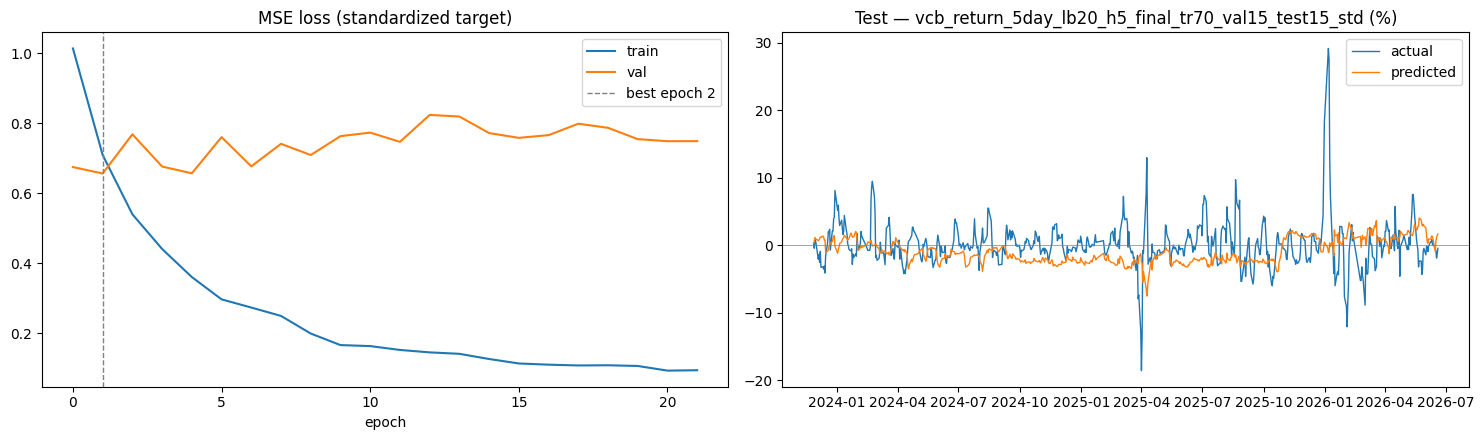

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

axes[0].plot(history["train"], label="train")
axes[0].plot(history["val"], label="val")
axes[0].axvline(trainer.best_epoch - 1, color="grey", ls="--", lw=1,
                label=f"best epoch {trainer.best_epoch}")
axes[0].set_title("MSE loss (standardized target)")
axes[0].set_xlabel("epoch"); axes[0].legend()

tp = preds["test"]
x = pd.to_datetime(tp["date"]) if "date" in tp else np.arange(len(tp))
axes[1].plot(x, tp["y_true"] * 100, label="actual", lw=1)
axes[1].plot(x, tp["y_pred"] * 100, label="predicted", lw=1)
axes[1].axhline(0, color="grey", lw=0.5)
axes[1].set_title(f"Test — {CONFIG['dataset']} (%)"); axes[1].legend()

plt.tight_layout()
fig.savefig(os.path.join(run.results_dir, "loss_and_predictions.png"), dpi=130, bbox_inches="tight")
plt.show()

## Finalize — write metrics + registry row

In [7]:
# results/metrics.json
with open(os.path.join(run.results_dir, "metrics.json"), "w") as f:
    json.dump(results, f, indent=2)

# metadata.json: fold in training summary + final metrics
run.update_metadata(
    model={"type": "LSTM", **arch["kwargs"], "n_params": int(n_params)},
    training={"best_epoch": int(trainer.best_epoch),
              "best_val_mse": float(trainer.best_val),
              **{k: getattr(tcfg, k) for k in ("batch_size", "lr", "weight_decay",
                                               "max_epochs", "patience")}},
    metrics=results,
)
trainer.close()

# runs/index.csv: one comparable row per run
append_run(RUNS_DIR, {
    "run_id": run.run_id,
    "created_at": run.metadata["created_at"],
    "dataset_name": dataset.name,
    "dataset_hash": dataset.hash,
    "model_type": "LSTM",
    "lookback": dataset.lookback,
    "n_features": dataset.n_features,
    "best_epoch": trainer.best_epoch,
    "best_val_mse": round(trainer.best_val, 6),
    "val_RMSE": round(results["val"]["RMSE"], 6),
    "val_dir_accuracy": round(results["val"]["dir_accuracy"], 4),
    "val_dir_auc": round(results["val"]["dir_auc"], 4),
    "val_spearman_ic": round(results["val"]["spearman_ic"], 4),
    "test_RMSE": round(results["test"]["RMSE"], 6),
    "test_RMSE_zero_baseline": round(results["test"]["RMSE_zero_baseline"], 6),
    "test_dir_accuracy": round(results["test"]["dir_accuracy"], 4),
    "test_dir_auc": round(results["test"]["dir_auc"], 4),
    "test_spearman_ic": round(results["test"]["spearman_ic"], 4),
    "test_beats_zero_baseline": results["test"]["beats_zero_baseline"],
    "git_sha": run.metadata["git_sha"],
    "run_dir": os.path.relpath(run.dir, os.path.abspath("..")),
})

print(f"Run complete -> {run.dir}\n")
for base, _dirs, files in os.walk(run.dir):
    rel = os.path.relpath(base, run.dir)
    print(f"  {'' if rel == '.' else rel + '/'}")
    for fn in sorted(files):
        size = os.path.getsize(os.path.join(base, fn)) / 1e6
        print(f"    {fn:26s} {size:8.3f} MB")
print(f"\nCompare runs:  tensorboard --logdir {RUNS_DIR}")

Run complete -> D:\GIT\master-thesis\src\model\runs\lstm__return_5day__lb20__final__20260703-204219

  
    config.yaml                   0.000 MB
    metadata.json                 0.003 MB
  logs/
  model/
    arch.json                     0.000 MB
    best.pt                       1.109 MB
    last.pt                       3.341 MB
  results/
    loss_and_predictions.png      0.118 MB
    loss_history.csv              0.001 MB
    metrics.json                  0.001 MB
    predictions_test.csv          0.024 MB
    predictions_val.csv           0.024 MB
  tensorboard/
    events.out.tfevents.1783086141.DESKTOP-TRDFIML.42376.0    0.003 MB
  tensorboard\1783086148.931721/
    events.out.tfevents.1783086148.DESKTOP-TRDFIML.42376.1    0.001 MB

Compare runs:  tensorboard --logdir D:\GIT\master-thesis\src\model\runs
